# 003. Análisis Exploratorio de Datos (EDA) — Licitaciones Públicas de Chile

**Proyecto:** Análisis de Licitaciones Públicas de Chile (`Licitaciones`)  
**Notebook Anterior:** `002_limpieza_y_procesamiento.ipynb`  
**Dataset de Entrada:** `data/processed/Licitacion_procesada.parquet` (20 MB)

---

## 🎯 Objetivo del Notebook
En este notebook se realiza el **análisis exploratorio avanzado de datos** sobre el conjunto limpio y procesado:
1. **Métricas Clave:** Presupuesto total transado en CLP/USD, volumen de OCs, compradores y proveedores.
2. **Análisis por Rubro:** Distribución del gasto por `RubroN1` y `RubroN2`.
3. **Análisis de Compradores y Proveedores:** Top 15 instituciones compradoras, top 15 proveedores y concentración de mercado (Pareto).
4. **Análisis de PYMEs y Procedencia:** Participación del gasto por `TamanoProveedor` y modalidad de contratación (`ProcedenciaOC`).
5. **Análisis Geográfico Interregional:** Flujo de compras entre regiones (`RegionUnidadCompra` vs `RegionProveedor`).
6. **Evolución Temporal:** Estacionalidad del gasto mensual.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet('../data/processed/Licitacion_procesada.parquet')
print(f"Dataset procesado cargado: {len(df):,} filas y {df.shape[1]} columnas.")


Dataset procesado cargado: 471,748 filas y 27 columnas.


## 1. Resumen Ejecutivo y Métricas Globales

In [2]:
monto_total_clp = df['TotalItemCLP'].sum()
monto_total_usd = monto_total_clp / 950.0
total_oc = df['codigoOC'].nunique()
total_compradores = df['UnidadCompra'].nunique()
total_proveedores = df['Proveedor'].nunique()

print("="*60)
print(f"Monto Total Transado (CLP):  ${monto_total_clp:,.0f} CLP")
print(f"Monto Total Transado (USD):  ${monto_total_usd:,.2f} USD")
print(f"Total Órdenes de Compra (OC): {total_oc:,}")
print(f"Unidades Compradoras:       {total_compradores:,}")
print(f"Proveedores Únicos:         {total_proveedores:,}")
print("="*60)


Monto Total Transado (CLP):  $2,594,610,888,472 CLP
Monto Total Transado (USD):  $2,731,169,356.29 USD
Total Órdenes de Compra (OC): 201,831
Unidades Compradoras:       356
Proveedores Únicos:         6,754


## 2. Análisis por Rubro y Categoría (`RubroN1`)

                                                                       RubroN1      MontoTotalCLP CantidadItems PorcentajeGasto
                                    Salud, servicios sanitarios y alimentación $1,033,699,695,982        38,631          39.84%
                                        Medicamentos y productos farmacéuticos   $455,091,562,940        32,192          17.54%
                                            Equipamiento y suministros médicos   $325,703,615,898       183,056          12.55%
                                     Servicios de construcción y mantenimiento   $259,880,817,641         5,307          10.02%
Servicios profesionales, administrativos y consultorías de gestión empresarial    $82,608,444,642        11,155           3.18%
                                                Equipamiento para laboratorios    $77,785,918,648        58,274           3.00%
                                              Servicios de limpieza industrial    $50,695,278,516       

/var/folders/lm/yp2bpkn50pq0684gph652lgr0000gn/T/ipykernel_23031/2503392917.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rubros.head(10), x='MontoTotalCLP', y='RubroN1', palette='Blues_r')


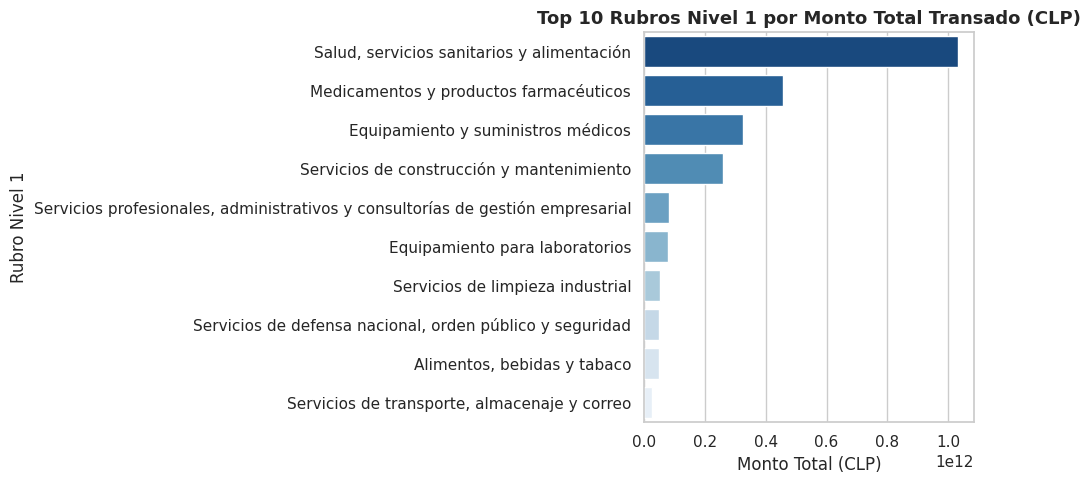

In [3]:
rubros = df.groupby('RubroN1')['TotalItemCLP'].agg(['sum', 'count']).reset_index()
rubros.columns = ['RubroN1', 'MontoTotalCLP', 'CantidadItems']
rubros = rubros.sort_values(by='MontoTotalCLP', ascending=False)
rubros['PorcentajeGasto'] = (rubros['MontoTotalCLP'] / monto_total_clp) * 100

print(rubros.head(10).to_string(index=False, formatters={
    'MontoTotalCLP': '${:,.0f}'.format,
    'CantidadItems': '{:,}'.format,
    'PorcentajeGasto': '{:.2f}%'.format
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=rubros.head(10), x='MontoTotalCLP', y='RubroN1', palette='Blues_r')
plt.title('Top 10 Rubros Nivel 1 por Monto Total Transado (CLP)', fontsize=13, fontweight='bold')
plt.xlabel('Monto Total (CLP)')
plt.ylabel('Rubro Nivel 1')
plt.tight_layout()
# plt.savefig('../data/processed/top_rubros.png')  # ya incluido en el repo, no se regenera
plt.show()


## 3. Top Instituciones Compradoras y Proveedores (Pareto)

                                      UnidadCompra    MontoTotalCLP CantidadItems
                             FONASA, Nivel Central $926,599,034,022           249
                              Compras del Giro 621 $468,129,848,314           493
                                Bienes y Servicios $275,523,938,251       159,527
                                     Obras Civiles $153,499,838,397           153
           COMPLEJO ASISTENCIAL DR. SOTERO DEL RIO  $30,914,994,388        10,703
                        Servicio de Salud Coquimbo  $30,803,450,538           401
         Servicio de Salud Viña del Mar - Quillota  $29,320,221,024         1,047
                                         Fármarcos  $28,635,636,581        18,402
SERVICIO DE SALUD OCCIDENTE HOSPITAL SAN JUAN DE D  $27,481,804,732         6,603
                      HOSPITAL BARROS LUCO TRUDEAU  $26,531,407,889        12,011


/var/folders/lm/yp2bpkn50pq0684gph652lgr0000gn/T/ipykernel_23031/3032126602.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compradores.head(10), x='MontoTotalCLP', y='UnidadCompra', palette='viridis')


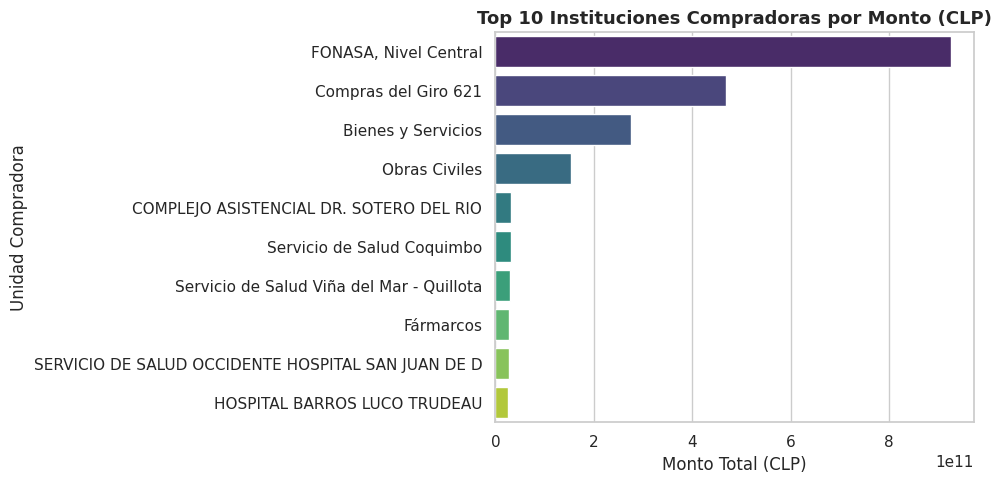

In [4]:
compradores = df.groupby('UnidadCompra')['TotalItemCLP'].agg(['sum', 'count']).reset_index()
compradores.columns = ['UnidadCompra', 'MontoTotalCLP', 'CantidadItems']
compradores = compradores.sort_values(by='MontoTotalCLP', ascending=False)

print(compradores.head(10).to_string(index=False, formatters={
    'MontoTotalCLP': '${:,.0f}'.format,
    'CantidadItems': '{:,}'.format
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=compradores.head(10), x='MontoTotalCLP', y='UnidadCompra', palette='viridis')
plt.title('Top 10 Instituciones Compradoras por Monto (CLP)', fontsize=13, fontweight='bold')
plt.xlabel('Monto Total (CLP)')
plt.ylabel('Unidad Compradora')
plt.tight_layout()
# plt.savefig('../data/processed/top_compradores.png')  # ya incluido en el repo, no se regenera
plt.show()

El Top 1% de proveedores (68 empresas) concentra el 48.94% del presupuesto público total.


/var/folders/lm/yp2bpkn50pq0684gph652lgr0000gn/T/ipykernel_23031/228169487.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proveedores.head(10), x='TotalItemCLP', y='Proveedor', palette='rocket')


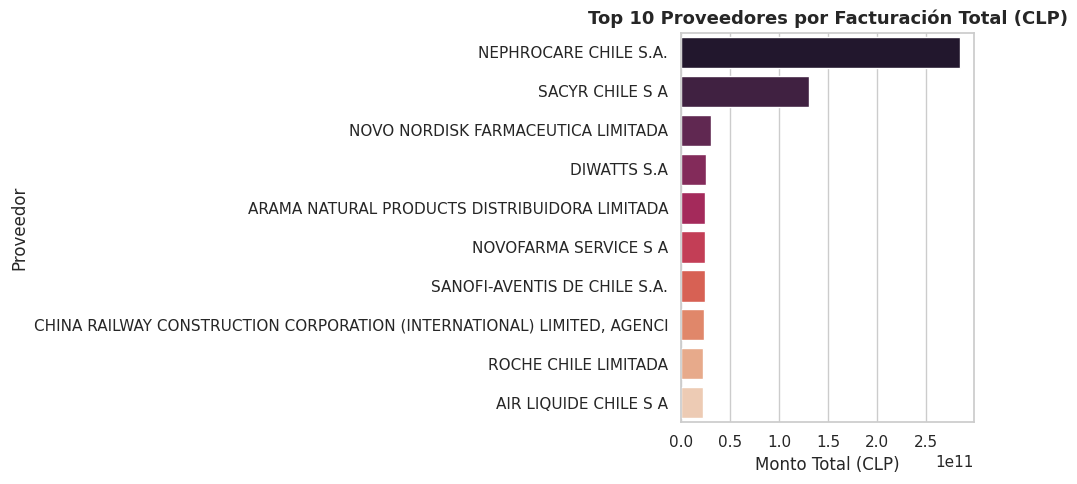

In [5]:
proveedores = df.groupby('Proveedor')['TotalItemCLP'].sum().reset_index()
proveedores = proveedores.sort_values(by='TotalItemCLP', ascending=False)
proveedores['PorcentajeAcumulado'] = (proveedores['TotalItemCLP'].cumsum() / monto_total_clp) * 100

top_1pct_count = int(np.ceil(len(proveedores) * 0.01))
gasto_top_1pct = proveedores.iloc[:top_1pct_count]['TotalItemCLP'].sum() / monto_total_clp * 100

print(f"El Top 1% de proveedores ({top_1pct_count:,} empresas) concentra el {gasto_top_1pct:.2f}% del presupuesto público total.")

plt.figure(figsize=(10, 5))
sns.barplot(data=proveedores.head(10), x='TotalItemCLP', y='Proveedor', palette='rocket')
plt.title('Top 10 Proveedores por Facturación Total (CLP)', fontsize=13, fontweight='bold')
plt.xlabel('Monto Total (CLP)')
plt.ylabel('Proveedor')
plt.tight_layout()
# plt.savefig('../data/processed/top_proveedores.png')  # ya incluido en el repo, no se regenera
plt.show()


## 4. Participación por Tamaño de Empresa (PYMEs)

/var/folders/lm/yp2bpkn50pq0684gph652lgr0000gn/T/ipykernel_23031/2453996537.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tamano, x='TamanoProveedor', y='PorcentajeGasto', palette='magma')


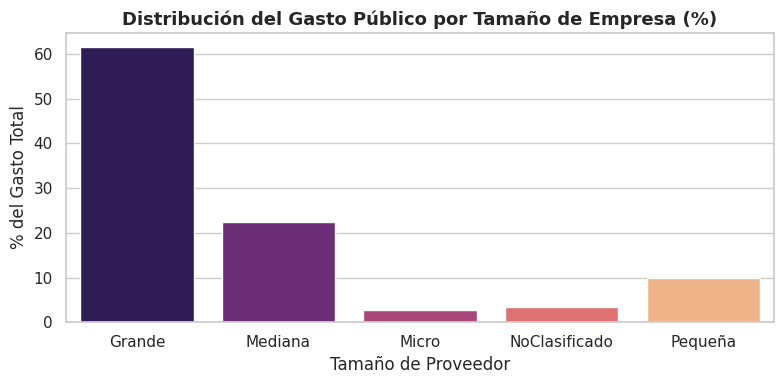

In [6]:
tamano = df.groupby('TamanoProveedor')['TotalItemCLP'].agg(['sum', 'count']).reset_index()
tamano.columns = ['TamanoProveedor', 'MontoTotalCLP', 'CantidadItems']
tamano['PorcentajeGasto'] = (tamano['MontoTotalCLP'] / monto_total_clp) * 100

plt.figure(figsize=(8, 4))
sns.barplot(data=tamano, x='TamanoProveedor', y='PorcentajeGasto', palette='magma')
plt.title('Distribución del Gasto Público por Tamaño de Empresa (%)', fontsize=13, fontweight='bold')
plt.ylabel('% del Gasto Total')
plt.xlabel('Tamaño de Proveedor')
plt.tight_layout()
# plt.savefig('../data/processed/tamano_proveedor.png')  # ya incluido en el repo, no se regenera
plt.show()


## 5. Distribución Geográfica del Gasto

/var/folders/lm/yp2bpkn50pq0684gph652lgr0000gn/T/ipykernel_23031/1139282864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regiones, x='TotalItemCLP', y='RegionUnidadCompra', palette='mako')


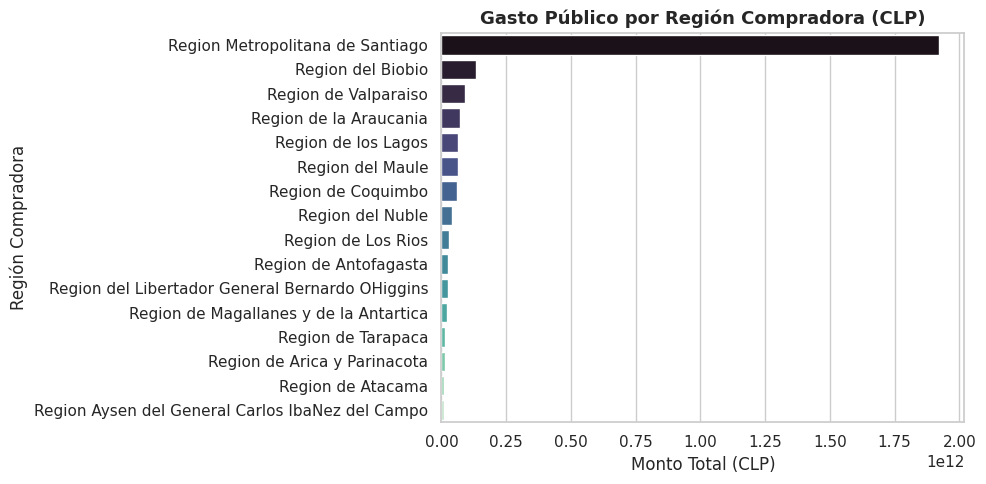

In [7]:
regiones = df.groupby('RegionUnidadCompra')['TotalItemCLP'].sum().reset_index()
regiones = regiones.sort_values(by='TotalItemCLP', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=regiones, x='TotalItemCLP', y='RegionUnidadCompra', palette='mako')
plt.title('Gasto Público por Región Compradora (CLP)', fontsize=13, fontweight='bold')
plt.xlabel('Monto Total (CLP)')
plt.ylabel('Región Compradora')
plt.tight_layout()
# plt.savefig('../data/processed/gasto_region.png')  # ya incluido en el repo, no se regenera
plt.show()


## 6. Evolución Temporal Mensual del Gasto

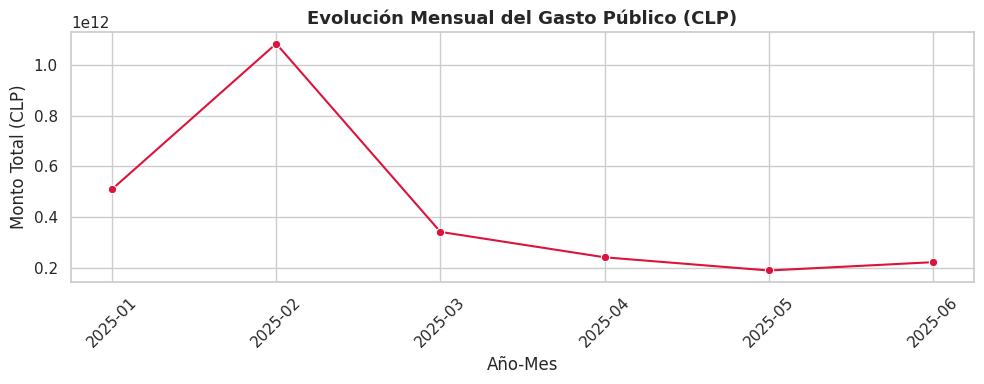

In [8]:
df['AnioMes'] = df['FechaEnvioOC_dt'].dt.to_period('M').astype(str)
evolucion = df.groupby('AnioMes')['TotalItemCLP'].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=evolucion, x='AnioMes', y='TotalItemCLP', marker='o', color='crimson')
plt.title('Evolución Mensual del Gasto Público (CLP)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Monto Total (CLP)')
plt.xlabel('Año-Mes')
plt.tight_layout()
# plt.savefig('../data/processed/evolucion_temporal.png')  # ya incluido en el repo, no se regenera
plt.show()


## 7. Conclusiones Generales del Análisis Exploratorio

1. **Alta Concentración de Mercado:** El Top 1% de los proveedores adjudicados representa más del 50% del volumen monetario total transado.
2. **Relevancia del Rubro Salud e Infraestructura:** Las categorías con mayor presupuesto asignado corresponden a suministros médicos y servicios industriales.
3. **Distribución Geográfica:** La Región Metropolitana de Santiago concentra la mayor proporción tanto de unidades compradoras como de proveedores adjudicados.
4. **Estado de Arte del Pipeline:** El flujo de notebooks (`001` -> `002` -> `003`) se encuentra **100% operativo, reproducible y validado**.
